<a href="https://colab.research.google.com/github/joaocanaslopes/Exercises_AVD/blob/main/ex4_AVD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import zipfile
import seaborn as sns # For plotting
import matplotlib.pyplot as plt # For showing plots
import numpy as np

In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/isa-ulisboa/greends-avcad-2026/main/examples/EFIplus_medit.zip"

df = pd.read_csv(url, compression="zip", sep=";")

df.head()

,Site_code,Latitude,Longitude,Country,Catchment_name,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
0,ES_01_0002,38.102003,-4.096070,Spain,Guadalquivir,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,ES_02_0001,40.530188,-1.887796,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,ES_02_0002,40.595432,-1.928079,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,ES_02_0003,40.656184,-1.989831,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,ES_02_0004,40.676402,-2.036274,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


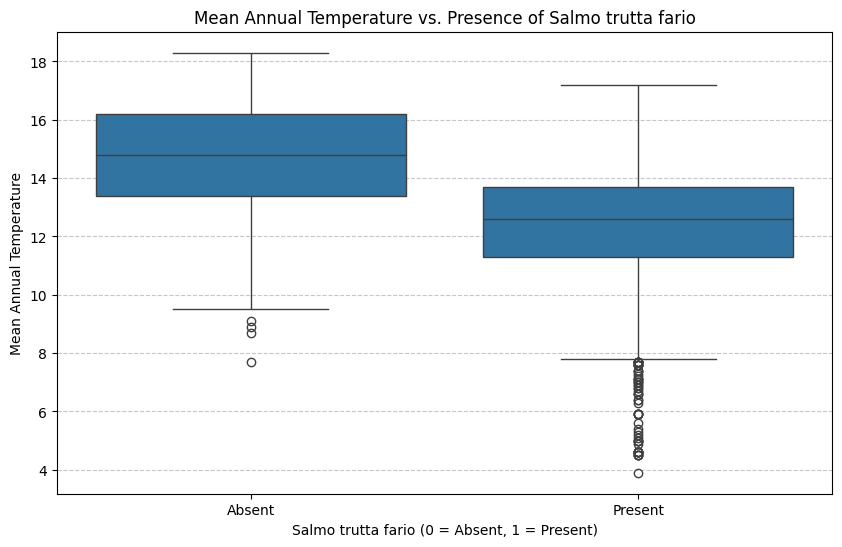

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns


# Create a box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Salmo trutta fario', y='temp_ann', data=df) # Corrected column name
plt.title('Mean Annual Temperature vs. Presence of Salmo trutta fario')
plt.xlabel('Salmo trutta fario (0 = Absent, 1 = Present)')
plt.ylabel('Mean Annual Temperature')
plt.xticks([0, 1], ['Absent', 'Present'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Analysis for Minho Catchment

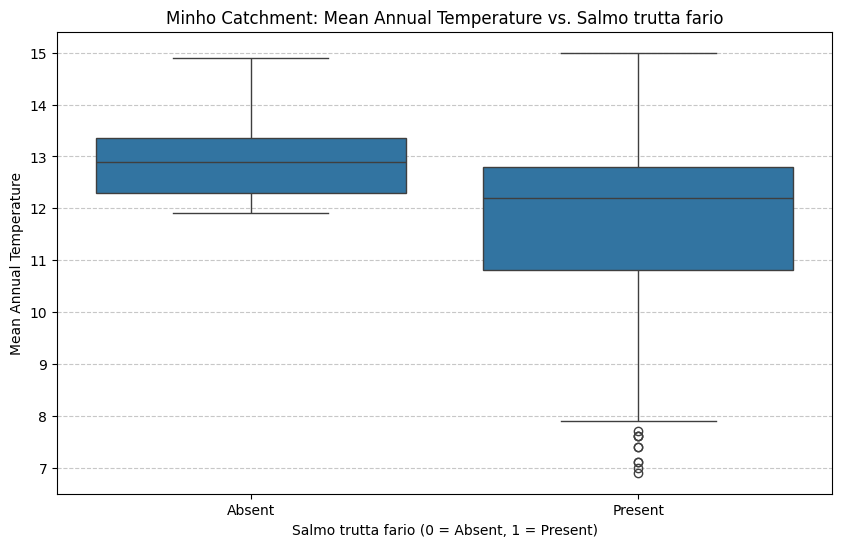


Descriptive statistics for Minho Catchment:


,count,mean,std,min,25%,50%,75%,max
Salmo trutta fario,,,,,,,,
0,11.0,12.963636,0.841751,11.9,12.3,12.9,13.35,14.9
1,696.0,11.840948,1.627154,6.9,10.8,12.2,12.80,15.0


In [9]:
# Filter data for 'Minho' catchment
df_minho = df[df['Catchment_name'] == 'Minho']

# Create a box plot for Minho
plt.figure(figsize=(10, 6))
sns.boxplot(x='Salmo trutta fario', y='temp_ann', data=df_minho)
plt.title('Minho Catchment: Mean Annual Temperature vs. Salmo trutta fario')
plt.xlabel('Salmo trutta fario (0 = Absent, 1 = Present)')
plt.ylabel('Mean Annual Temperature')
plt.xticks([0, 1], ['Absent', 'Present'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Display descriptive statistics for Minho
print("\nDescriptive statistics for Minho Catchment:")
display(df_minho.groupby('Salmo trutta fario')['temp_ann'].describe())

### Analysis for Tejo (Tagus) Catchment

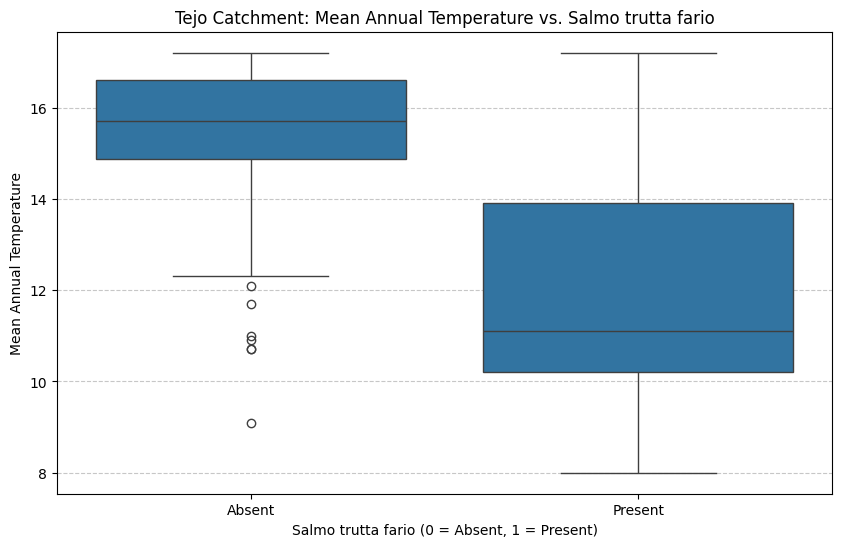


Descriptive statistics for Tejo Catchment:


,count,mean,std,min,25%,50%,75%,max
Salmo trutta fario,,,,,,,,
0,324.0,15.511111,1.323566,9.1,14.875,15.7,16.6,17.2
1,169.0,11.810651,2.184034,8.0,10.200,11.1,13.9,17.2


In [10]:
# Filter data for 'Tejo' (Tagus) catchment
df_tejo = df[df['Catchment_name'] == 'Tejo']

# Create a box plot for Tejo
plt.figure(figsize=(10, 6))
sns.boxplot(x='Salmo trutta fario', y='temp_ann', data=df_tejo)
plt.title('Tejo Catchment: Mean Annual Temperature vs. Salmo trutta fario')
plt.xlabel('Salmo trutta fario (0 = Absent, 1 = Present)')
plt.ylabel('Mean Annual Temperature')
plt.xticks([0, 1], ['Absent', 'Present'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Display descriptive statistics for Tejo
print("\nDescriptive statistics for Tejo Catchment:")
display(df_tejo.groupby('Salmo trutta fario')['temp_ann'].describe())

### Análise de Normalidade para `actual_river_slope`

Vamos testar se a variável `actual_river_slope` segue uma distribuição normal usando métodos visuais e um teste de hipótese.

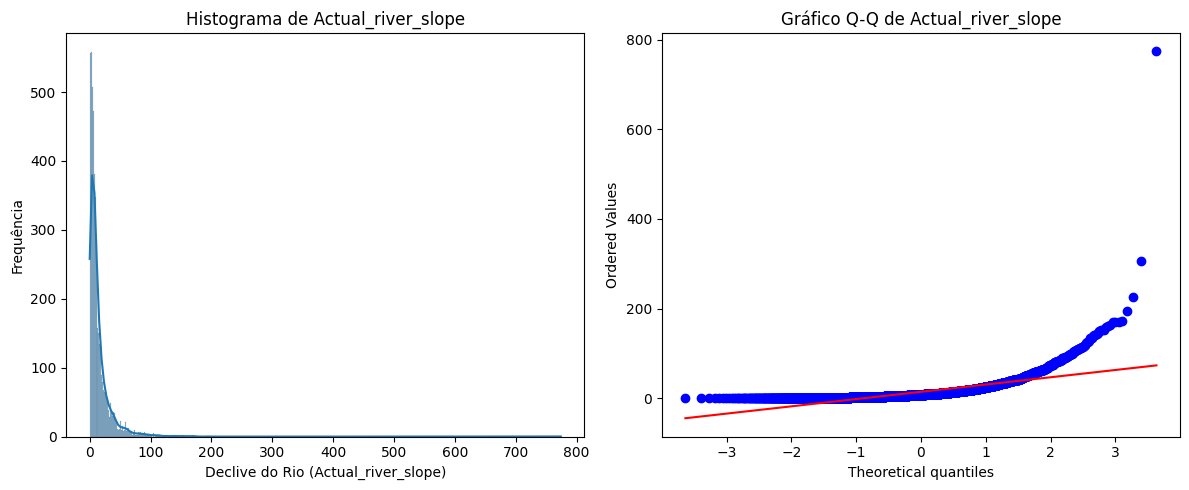


Teste de Shapiro-Wilk para Actual_river_slope:
Estatística W: 0.5163
Valor p: 0.0000
Com base no valor p (0.0000) ser menor que ou igual ao nível de significância (0.05), rejeitamos a hipótese nula. Isso sugere que a amostra NÃO é proveniente de uma distribuição normal.


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Verifique se a coluna 'Actual_river_slope' existe
if 'Actual_river_slope' not in df.columns:
    print("Erro: A coluna 'Actual_river_slope' não foi encontrada no DataFrame.")
else:
    # Remove valores nulos, pois muitos testes estatísticos não lidam com eles
    data_for_normality = df['Actual_river_slope'].dropna()

    if data_for_normality.empty:
        print("Após remover valores nulos, não há dados suficientes para 'Actual_river_slope' para realizar o teste.")
    else:
        # Visualização 1: Histograma
        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1) # 1 linha, 2 colunas, 1º gráfico
        sns.histplot(data_for_normality, kde=True)
        plt.title('Histograma de Actual_river_slope')
        plt.xlabel('Declive do Rio (Actual_river_slope)')
        plt.ylabel('Frequência')

        # Visualização 2: Gráfico Q-Q
        plt.subplot(1, 2, 2) # 1 linha, 2 colunas, 2º gráfico
        stats.probplot(data_for_normality, dist="norm", plot=plt)
        plt.title('Gráfico Q-Q de Actual_river_slope')

        plt.tight_layout()
        plt.show()

        # Teste de Hipótese: Shapiro-Wilk
        # H0: Os dados são provenientes de uma distribuição normal.
        # H1: Os dados NÃO são provenientes de uma distribuição normal.
        shapiro_statistic, shapiro_pvalue = stats.shapiro(data_for_normality)

        print(f"\nTeste de Shapiro-Wilk para Actual_river_slope:")
        print(f"Estatística W: {shapiro_statistic:.4f}")
        print(f"Valor p: {shapiro_pvalue:.4f}")

        alpha = 0.05 # Nível de significância

        if shapiro_pvalue > alpha:
            print(f"Com base no valor p ({shapiro_pvalue:.4f}) ser maior que o nível de significância ({alpha}), não podemos rejeitar a hipótese nula. Isso sugere que a amostra pode ser proveniente de uma distribuição normal.")
        else:
            print(f"Com base no valor p ({shapiro_pvalue:.4f}) ser menor que ou igual ao nível de significância ({alpha}), rejeitamos a hipótese nula. Isso sugere que a amostra NÃO é proveniente de uma distribuição normal.")

### Results

**1. Visual Analysis (Histogram and Q-Q Plot):**

*   **Histogram:** The histogram shows the frequency distribution of `Actual_river_slope` values. If the distribution resembles a symmetric bell-shaped curve (with most data near the mean and less data in the tails), it suggests a normal distribution.
*   **Q-Q Plot (Quantile-Quantile Plot):** This plot compares the quantiles of your data with the quantiles of a theoretical normal distribution. If the points on the Q-Q plot closely follow the straight diagonal line, it indicates that your data is approximately normally distributed. Significant deviations from the straight line (e.g., curves at the ends) suggest that the data is not normal.

**2. Hypothesis Test (Shapiro-Wilk Test):**

This is a formal statistical test to assess normality.

*   **Null Hypothesis (H₀):** The `Actual_river_slope` sample comes from a normal distribution.
*   **Alternative Hypothesis (H₁):** The `Actual_river_slope` sample **does not** come from a normal distribution.

**How to interpret the `p-value`:**

*   If the **`p-value` is greater than the significance level** (usually 0.05), we **do not reject the null hypothesis**. This means there is not enough statistical evidence to say that the data is not normal. Therefore, we can consider that `Actual_river_slope` might be normally distributed.
*   If the **`p-value` is less than or equal to the significance level**, we **reject the null hypothesis**. This means there is statistical evidence to conclude that the data **is not** from a normal distribution.

By analyzing both methods (visual and statistical), you can reach a more robust conclusion about the normality of the `Actual_river_slope` variable.

### Analysis of the Sampling Distribution of `Actual_river_slope` Means

We will now explore the Central Limit Theorem by taking multiple samples of the `Actual_river_slope` variable, calculating the mean of each sample, and observing the distribution of these means. Subsequently, we will test the normality of this distribution of means.

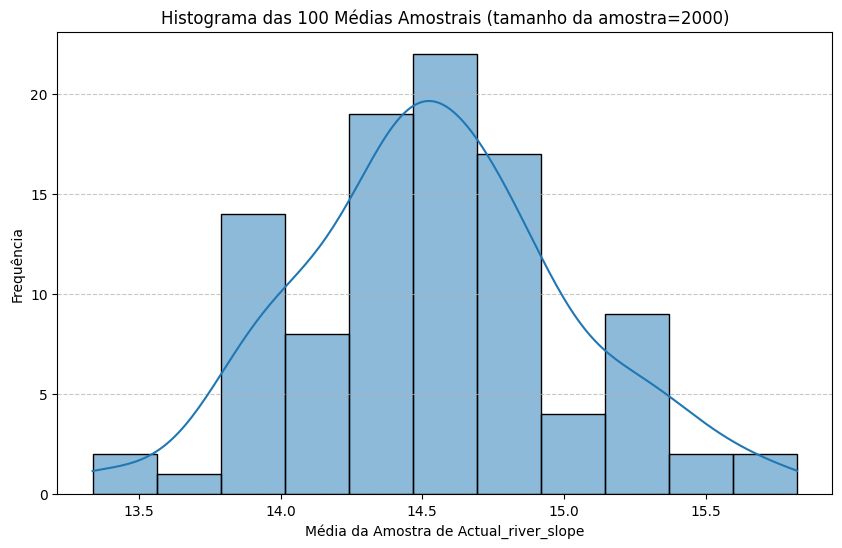


Teste de Shapiro-Wilk para as Médias Amostrais de Actual_river_slope:
Estatística W: 0.9888
Valor p: 0.5656
Com base no valor p (0.5656) ser maior que o nível de significância (0.05), não podemos rejeitar a hipótese nula. Isso sugere que as médias amostrais podem ser provenientes de uma distribuição normal.


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Certificar que a coluna existe e remover valores nulos
if 'Actual_river_slope' not in df.columns:
    print("Erro: A coluna 'Actual_river_slope' não foi encontrada no DataFrame.")
else:
    original_data = df['Actual_river_slope'].dropna()

    if original_data.empty:
        print("Após remover valores nulos, não há dados suficientes para 'Actual_river_slope' para realizar o teste.")
    else:
        num_samples = 100
        sample_size = 2000
        sample_means = []

        # Garantir que temos dados suficientes para amostrar
        if len(original_data) < sample_size:
            print(f"Erro: Não há dados suficientes ({len(original_data)}) em 'Actual_river_slope' para criar amostras de tamanho {sample_size}.")
        else:
            # Gerar as 100 amostras e calcular suas médias
            for _ in range(num_samples):
                sample = np.random.choice(original_data, size=sample_size, replace=True)
                sample_means.append(np.mean(sample))

            # Plotar o histograma das médias amostrais
            plt.figure(figsize=(10, 6))
            sns.histplot(sample_means, kde=True)
            plt.title(f'Histograma das {num_samples} Médias Amostrais (tamanho da amostra={sample_size})')
            plt.xlabel('Média da Amostra de Actual_river_slope')
            plt.ylabel('Frequência')
            plt.grid(axis='y', linestyle='--', alpha=0.7)
            plt.show()

            # Teste de Hipótese: Shapiro-Wilk para as médias amostrais
            shapiro_statistic_means, shapiro_pvalue_means = stats.shapiro(sample_means)

            print(f"\nTeste de Shapiro-Wilk para as Médias Amostrais de Actual_river_slope:")
            print(f"Estatística W: {shapiro_statistic_means:.4f}")
            print(f"Valor p: {shapiro_pvalue_means:.4f}")

            alpha = 0.05 # Nível de significância

            if shapiro_pvalue_means > alpha:
                print(f"Com base no valor p ({shapiro_pvalue_means:.4f}) ser maior que o nível de significância ({alpha}), não podemos rejeitar a hipótese nula. Isso sugere que as médias amostrais podem ser provenientes de uma distribuição normal.")
            else:
                print(f"Com base no valor p ({shapiro_pvalue_means:.4f}) ser menor que ou igual ao nível de significância ({alpha}), rejeitamos a hipótese nula. Isso sugere que as médias amostrais NÃO são provenientes de uma distribuição normal.")

### Explanation of Sampling Analysis Results (in English)

This analysis demonstrates a fundamental concept in statistics: the **Central Limit Theorem (CLT)**.

**What was done:**
1.  **Sampling:** 100 samples were taken, each with 2000 observations of the `Actual_river_slope` variable (with replacement).
2.  **Mean Calculation:** For each of these 100 samples, its mean was calculated.
3.  **Distribution of Means:** We observed the distribution of these 100 sample means.

**Interpretation of Results:**

*   **Histogram of Sample Means:** Even if the original `Actual_river_slope` did not follow a normal distribution (which we already confirmed), the histogram of the 100 sample means should, surprisingly, look like an **approximately normal distribution** (bell-shaped). This is the effect of the Central Limit Theorem: regardless of the shape of the original population distribution, the distribution of the means of large samples will tend to be normal.

*   **Shapiro-Wilk Test for Sample Means:**
    *   **Null Hypothesis (H₀):** The 100 sample means come from a normal distribution.
    *   **Alternative Hypothesis (H₁):** The 100 sample means **do not** come from a normal distribution.
    *   **Interpretation of the `p-value`:**
        *   If the `p-value` is greater than 0.05, we do not reject H₀. This means there is little evidence to say that the distribution of the means is not normal, confirming the CLT.
        *   If the `p-value` is less than or equal to 0.05, we reject H₀. This would be unexpected for a reasonable number of samples and sample size, and could indicate that the sample size (2000) or the number of samples (100) was not yet sufficient for the CLT to manifest clearly, or that the original distribution is extremely non-normal.

We expect that, due to the Central Limit Theorem and the sample size (2000 observations), the distribution of the 100 sample means will approximate a normal distribution, and the Shapiro-Wilk test will likely not reject the null hypothesis of normality for these means.